<a href="https://colab.research.google.com/github/asheta66/Machine-Learning-2024/blob/main/OSA/OSA_Using_Evolutionary_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

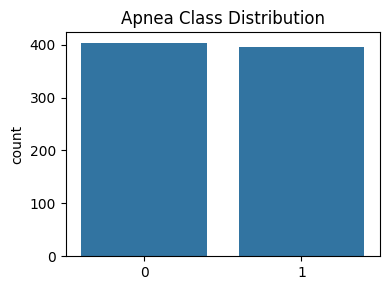

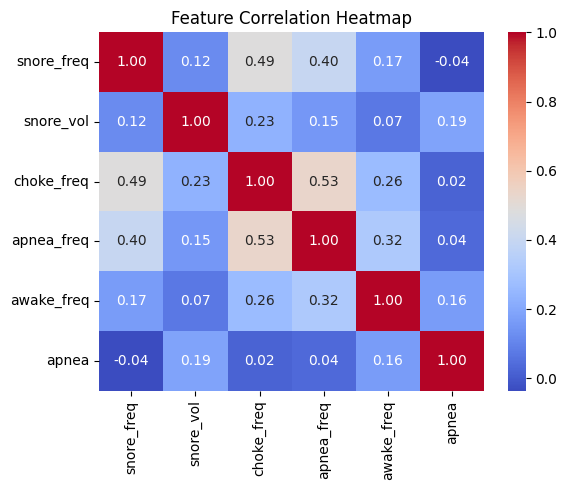

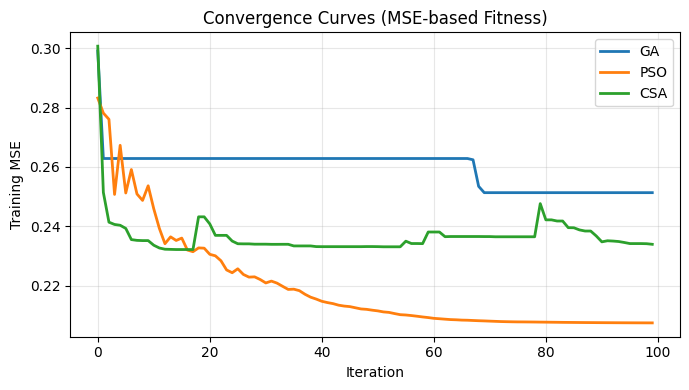

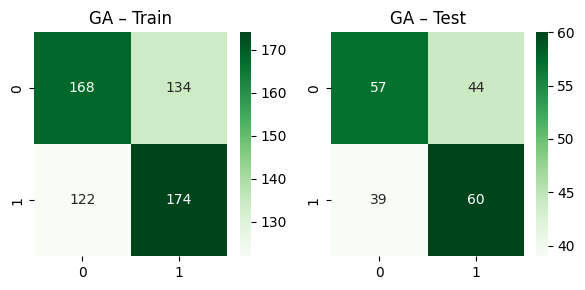

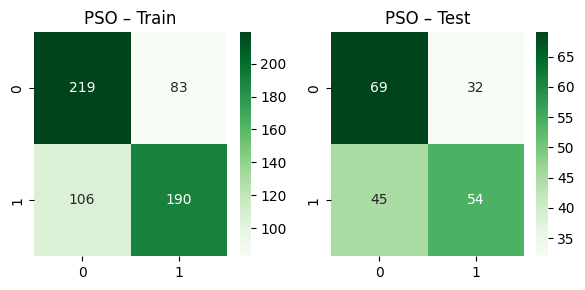

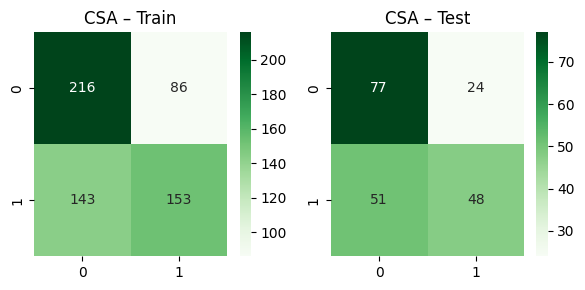

=== Results Table ===
           GA-Train   GA-Test  PSO-Train  PSO-Test  CSA-Train  CSA-Test
Accuracy   0.571906  0.585000   0.683946  0.615000   0.617057  0.625000
Precision  0.564935  0.576923   0.695971  0.627907   0.640167  0.666667
Recall     0.587838  0.606061   0.641892  0.545455   0.516892  0.484848
F1-score   0.576159  0.591133   0.667838  0.583784   0.571963  0.561404


In [7]:
# ==========================================================
# 1. IMPORT LIBRARIES
# ==========================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score
)

np.random.seed(42)

# ==========================================================
# 2. USER-TUNABLE PARAMETERS
# ==========================================================
N_HIDDEN = 30          # number of neurons in hidden layer
POP_SIZE = 30          # population/colony size
ITERATIONS = 100       # number of iterations/generations
CROSS_RATE = 0.8       # GA crossover rate
MUT_RATE = 0.01        # GA mutation rate

# PSO parameters
W = 0.5
C1 = 1.5
C2 = 1.5

# ==========================================================
# 3. LOAD & PREPROCESS DATA
# ==========================================================
df = pd.read_csv("sleep_disordered_breathing.csv")

# Features and label
X = df.drop(columns=["apnea"]).values
y = df["apnea"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.25, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==========================================================
# 4. DATA VISUALIZATION
# ==========================================================
plt.figure(figsize=(4,3))
sns.countplot(x=y)
plt.title("Apnea Class Distribution")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,5))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# ==========================================================
# 5. ANN MODEL & FITNESS (MSE-based)
# ==========================================================
def ann_forward(X, weights):
    w1, b1, w2, b2 = weights
    a1 = np.tanh(X @ w1 + b1)
    z2 = a1 @ w2 + b2
    z2 = np.clip(z2, -20, 20)
    return 1 / (1 + np.exp(-z2))

def decode_weights(vec, n_in, n_h):
    idx = 0
    w1 = vec[idx:idx+n_in*n_h].reshape(n_in, n_h)
    idx += n_in*n_h
    b1 = vec[idx:idx+n_h]
    idx += n_h
    w2 = vec[idx:idx+n_h].reshape(n_h,1)
    idx += n_h
    b2 = vec[idx]
    return w1, b1, w2, b2

DIM = X_train.shape[1]*N_HIDDEN + N_HIDDEN + N_HIDDEN + 1

def fitness(pop):
    """Fitness = training MSE (to minimize)."""
    f = np.zeros(len(pop))
    for i, ind in enumerate(pop):
        w = decode_weights(ind, X_train.shape[1], N_HIDDEN)
        y_hat = ann_forward(X_train, w).flatten()
        f[i] = np.mean((y_train - y_hat)**2)  # MSE
    return f

# ==========================================================
# 6. GENETIC ALGORITHM (GA)
# ==========================================================
def GA():
    pop = np.random.uniform(-1, 1, (POP_SIZE, DIM))
    history = []

    for t in range(ITERATIONS):
        fit = fitness(pop)
        history.append(float(np.min(fit)))

        # Selection (tournament)
        idx = np.argsort(fit)
        elite = pop[idx[:int(0.2*POP_SIZE)]].copy()

        # Crossover & Mutation
        children = []
        while len(children) < POP_SIZE - len(elite):
            p1, p2 = elite[np.random.choice(len(elite), 2, replace=False)]
            if np.random.rand() < CROSS_RATE:
                point = np.random.randint(1, DIM)
                c = np.concatenate([p1[:point], p2[point:]])
            else:
                c = p1.copy()
            if np.random.rand() < MUT_RATE:
                c += 0.1 * np.random.randn(DIM)
            children.append(c)

        pop = np.vstack([elite] + children[:POP_SIZE - len(elite)])

    best_idx = np.argmin(fitness(pop))
    return pop[best_idx], history

# ==========================================================
# 7. PARTICLE SWARM OPTIMIZATION (PSO)
# ==========================================================
def PSO():
    pop = np.random.uniform(-1,1,(POP_SIZE,DIM))
    vel = np.zeros_like(pop)
    pbest = pop.copy()
    pbest_fit = fitness(pop)
    gbest = pop[np.argmin(pbest_fit)]
    history = []

    for _ in range(ITERATIONS):
        fit = fitness(pop)
        history.append(float(np.min(fit)))

        for i in range(POP_SIZE):
            if fit[i] < pbest_fit[i]:
                pbest[i] = pop[i].copy()
                pbest_fit[i] = fit[i]

        gbest = pbest[np.argmin(pbest_fit)]

        r1 = np.random.rand(POP_SIZE, DIM)
        r2 = np.random.rand(POP_SIZE, DIM)
        vel = W*vel + C1*r1*(pbest-pop) + C2*r2*(gbest-pop)
        pop += vel

    return gbest, history

# ==========================================================
# 8. CROW SEARCH ALGORITHM (CSA)
# ==========================================================
def CSA():
    crows = np.random.uniform(-1, 1, (POP_SIZE, DIM))
    memory = crows.copy()
    history = []

    for _ in range(ITERATIONS):
        fit = fitness(crows)
        history.append(float(np.min(fit)))
        best = crows[np.argmin(fit)]

        for i in range(POP_SIZE):
            if np.random.rand() < 0.8:
                crows[i] += np.random.rand() * (best - memory[i])
            else:
                crows[i] = np.random.uniform(-1, 1, DIM)

        memory = crows.copy()

    return best, history

# ==========================================================
# 9. TRAIN MODELS
# ==========================================================
best_ga, hist_ga = GA()
best_pso, hist_pso = PSO()
best_csa, hist_csa = CSA()

# ==========================================================
# 10. CONVERGENCE CURVES (MSE)
# ==========================================================
plt.figure(figsize=(7,4))
plt.plot(hist_ga, label="GA", linewidth=2)
plt.plot(hist_pso, label="PSO", linewidth=2)
plt.plot(hist_csa, label="CSA", linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Training MSE")
plt.title("Convergence Curves (MSE-based Fitness)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ==========================================================
# 11. EVALUATION + CONFUSION MATRICES
# ==========================================================
def evaluate_and_plot(best, name):
    w = decode_weights(best, X_train.shape[1], N_HIDDEN)

    ytr_prob = ann_forward(X_train, w).flatten()
    yte_prob = ann_forward(X_test, w).flatten()

    ytr_pred = (ytr_prob > 0.5).astype(int)
    yte_pred = (yte_prob > 0.5).astype(int)

    # Plot confusion matrices side by side
    fig, ax = plt.subplots(1, 2, figsize=(6,3))
    sns.heatmap(confusion_matrix(y_train, ytr_pred),
                annot=True, fmt="d", cmap="Greens", ax=ax[0])
    sns.heatmap(confusion_matrix(y_test, yte_pred),
                annot=True, fmt="d", cmap="Greens", ax=ax[1])
    ax[0].set_title(f"{name} – Train")
    ax[1].set_title(f"{name} – Test")
    plt.tight_layout()
    plt.show()

    return ytr_pred, yte_pred

preds = {
    "GA": evaluate_and_plot(best_ga, "GA"),
    "PSO": evaluate_and_plot(best_pso, "PSO"),
    "CSA": evaluate_and_plot(best_csa, "CSA")
}

# ==========================================================
# 12. RESULTS TABLE (TRAIN + TEST HORIZONTAL)
# ==========================================================
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
table = {}

for algo, (ytrp, ytep) in preds.items():
    table[f"{algo}-Train"] = [
        accuracy_score(y_train, ytrp),
        precision_score(y_train, ytrp),
        recall_score(y_train, ytrp),
        f1_score(y_train, ytrp)
    ]
    table[f"{algo}-Test"] = [
        accuracy_score(y_test, ytep),
        precision_score(y_test, ytep),
        recall_score(y_test, ytep),
        f1_score(y_test, ytep)
    ]

df_results = pd.DataFrame(table, index=metrics)

print("=== Results Table ===")
print(df_results)
